In [1]:
import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import random
import numpy as np

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
import insertHybrid
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict

seed = 16
random.seed(seed)
np.random.seed(seed)

In [2]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 3)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5   #### hier kann die ANzahl der durchschnittlichen Kinder ausgewählt werden
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, pruned_gene_tree)
# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

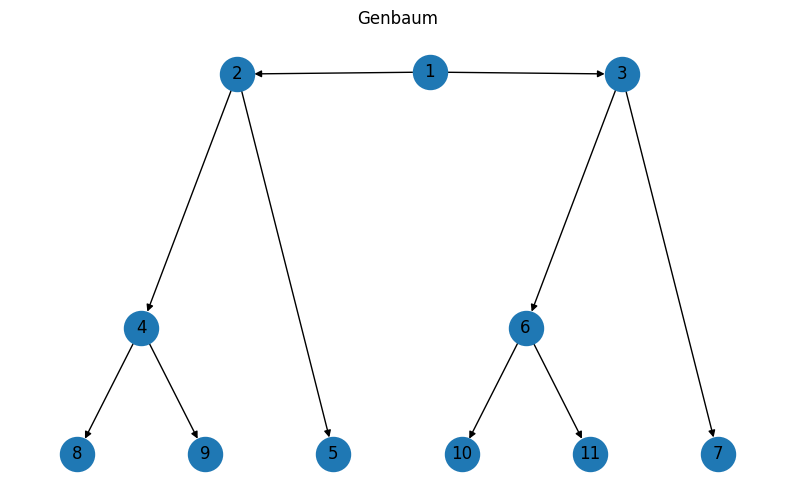

[(1, {'label': 1, 'event': 'D', 'reconc': (0, 1), 'tstamp': 0.5576994609201474, 'transferred': 0, 'dist': 0.0}), (2, {'label': 2, 'event': 'S', 'reconc': 1, 'tstamp': 0.5548211515246664, 'transferred': 0, 'dist': np.float64(0.0025433132586401524), 'sibling_nr': 0}), (4, {'label': 4, 'event': 'S', 'reconc': 3, 'tstamp': 0.18453051075454785, 'transferred': 0, 'dist': np.float64(0.2760806078661334), 'sibling_nr': 0}), (8, {'label': 8, 'event': 'S', 'reconc': 4, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.1363532518374126), 'sibling_nr': 0}), (9, {'label': 9, 'event': 'S', 'reconc': 5, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.5053483821440613), 'sibling_nr': 1}), (5, {'label': 5, 'event': 'S', 'reconc': 2, 'tstamp': 0.0, 'transferred': 0, 'dist': np.float64(0.4442800265735066), 'sibling_nr': 1}), (3, {'label': 3, 'event': 'S', 'reconc': 1, 'tstamp': 0.5548211515246664, 'transferred': 0, 'dist': np.float64(0.0018919905780624357), 'sibling_nr': 1}), (6, {'label': 6, 'e

In [3]:
N = insertHybrid.convert_to_nx(pruned_gene_tree)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

fig, ax = plt.subplots(figsize=(10, 6))

nx.draw(N,pos= pos,
        labels=labels,
        node_size=600,
        arrows=True,
        ax=ax)

plt.title('Genbaum')
plt.show()

print(N.nodes(data = True))

Es wurde ein Hybrid zwischen node 3 und node 6 eingefügt und dieser wurde mit Node 5 verbunden
Es wurde ein Hybrid zwischen node 3 und node 12 eingefügt und dieser wurde mit Node 10 verbunden
Es wurde ein Hybrid zwischen node 2 und node 5 eingefügt und dieser wurde mit Node 7 verbunden
Es wurde ein Hybrid zwischen node 3 und node 7 eingefügt und dieser wurde mit Node 4 verbunden
Es wurde ein Hybrid zwischen node 15 und node 7 eingefügt und dieser wurde mit Node 5 verbunden
Es wurde ein Hybrid zwischen node 4 und node 9 eingefügt und dieser wurde mit Node 5 verbunden


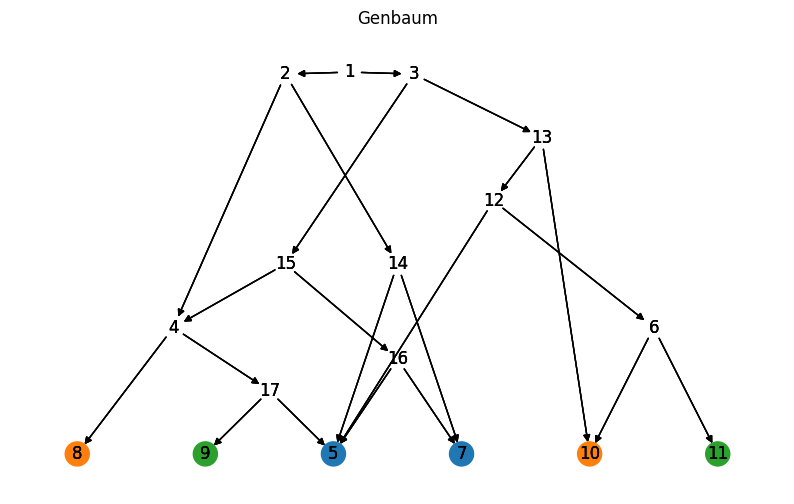

In [4]:
N = insertHybrid.insertHybrid(N,6)

# ── Labels: node.label Attribut ──────────────────────────
labels = {n: N.nodes[n]['label'] for n in N.nodes}

pos = insertHybrid.calculate_time_tree_layout(N)

# ── Plot ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

for color, node_list in color_to_keys.items():
    nx.draw(N,
            pos,
            nodelist=node_list,
            node_color=[color] * len(node_list),
            with_labels=True)

plt.title('Genbaum')
plt.show()

# for node in G.nodes(data=True):
#     print(node)

True


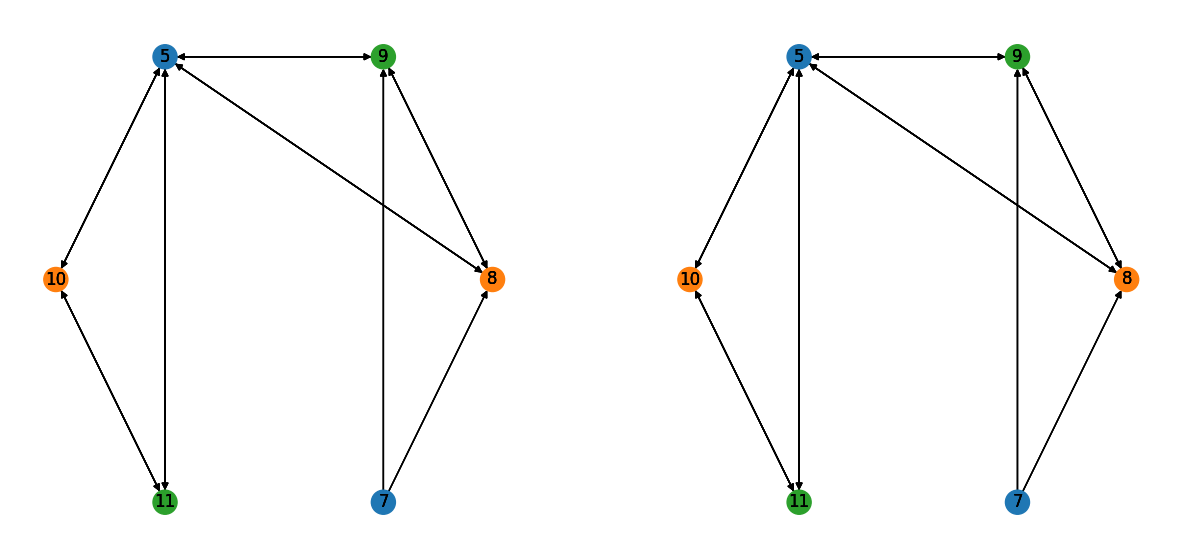

In [7]:
G = insertHybrid.bmg(N)
G_strong = insertHybrid.bmg(N,"strong")

print(nx.utils.graphs_equal(G, G_strong))

ig, axes = plt.subplots(1, 2, figsize=(15, 7))
# Tree BMG
for color, node_list in color_to_keys.items():
    nx.draw(G, nx.circular_layout(G), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[0], with_labels=True)
# network BMG
for color, node_list in color_to_keys.items():
    nx.draw(G_strong, nx.circular_layout(G_strong), nodelist=node_list, node_color=[color] * len(node_list), ax=axes[1], with_labels=True)